<a href="https://colab.research.google.com/github/ipavlopoulos/greek-letter-vision/blob/main/fCNN%2BSCL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%%capture
!gdown 1CMcTsxSzz6vzvrq_OIwOJFtowI3KHPOa
!gdown 1JnaVPaqDA60zpT7gkq6VtIPf8nlBGi87
!unzip Timeline20250531.zip

In [2]:
#@title Load Data
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
from sklearn.decomposition import PCA
import numpy as np
from PIL import Image
import cv2
import pandas as pd

image_folder = 'Timeline20250531/cliplets/'
image_files = [os.path.join(image_folder, f) for f in os.listdir(image_folder) if f.endswith(('.jpg', '.jpeg', '.png'))]

# Function to preprocess images (resize, binariz, normalize eand flatten)
def preprocess_image(image_path, size=(64, 64)):
    # Load image and convert to grayscale
    img = Image.open(image_path).convert('L')
    img_np = np.array(img)

    # Binarization using Otsu's method
    _, img_bin = cv2.threshold(img_np, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Invert image: black on white background
    img_bin = 255 - img_bin

    # Resize to standard size
    img_resized = cv2.resize(img_bin, size, interpolation=cv2.INTER_AREA)

    # Normalize pixel values to [0, 1]
    img_normalized = img_resized.astype(np.float32) / 255.0

    # Flatten and return
    return img_normalized.flatten()

# Preprocess all images
image_data = []
for img_file in image_files:
    try:
        processed_img = preprocess_image(img_file)
        image_data.append(processed_img)
    except Exception as e:
        print(f"Error processing image {img_file}: {e}")

image_data = np.array(image_data)

# Adding metadata
filenames = os.listdir('Timeline20250531/cliplets/')
data = pd.DataFrame({'filename': filenames})
data['letter'] = data.filename.apply(lambda x: x.split('_')[0])
data['TM'] = data.filename.apply(lambda x: int(x.split('_')[1]))
data['number'] = data.filename.apply(lambda x: x.split('_')[2].split('.')[0])

metadata = pd.read_csv('metadata.csv')

data['year'] = data.TM.apply(lambda x: metadata.loc[metadata['TM'] == x]['Year ante quem'].values[0])
data['region'] = data.TM.apply(lambda x: metadata.loc[metadata['TM'] == x]['Production Nome (supposed)'].values[0])

In [3]:
#@title Preprocess
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import torchvision.transforms as transforms
import torch
import numpy as np
import cv2
import random

class RandomLacunae(object):
    """
    Apply lacunae-like erasures to simulate missing text regions (irregular blobs).
    """
    def __init__(self, num_lacunae=(1, 4), size_range=(0.02, 0.15), p=0.5, v=0.5):
        """
        Args:
            num_lacunae (tuple): min/max number of lacunae per image
            size_range (tuple): relative size range (as fraction of image area)
            p (float): probability of applying the augmentation
        """
        self.num_lacunae = num_lacunae
        self.size_range = size_range
        self.p = p
        self.v = v

    def __call__(self, img):
        if random.random() > self.p:
            return img

        img_np = np.array(img).copy()
        h, w = img_np.shape[:2]

        for _ in range(random.randint(*self.num_lacunae)):
            # Random size relative to image
            lacuna_area = random.uniform(*self.size_range) * h * w
            lacuna_w = int(np.sqrt(lacuna_area) * random.uniform(0.5, 1.5))
            lacuna_h = int(np.sqrt(lacuna_area) * random.uniform(0.5, 1.5))

            # Random center
            x = random.randint(0, w - 1)
            y = random.randint(0, h - 1)

            # Create irregular blob mask using cv2 ellipse + random contour distortion
            mask = np.zeros((h, w), dtype=np.uint8)
            cv2.ellipse(mask, (x, y), (lacuna_w//2, lacuna_h//2),
                        angle=random.randint(0, 180),
                        startAngle=0, endAngle=360,
                        color=1, thickness=-1)

            # Optionally: erode/dilate with noise to add irregularity
            if random.random() < 0.7:
                kernel_size = random.choice([3,5,7])
                kernel = np.ones((kernel_size,kernel_size), np.uint8)
                if random.random() < 0.5:
                    mask = cv2.erode(mask, kernel, iterations=1)
                else:
                    mask = cv2.dilate(mask, kernel, iterations=1)

            # Apply lacuna (set pixels to background = white/255)
            img_np[mask == 1] = 255 * self.v  # assuming grayscale / white parchment

        return torch.tensor(img_np) if isinstance(img, torch.Tensor) else img_np

# Preprocess images for 2D CNN (resize and normalize, no flattening yet)
def preprocess_image_2d(image_path, size=(64, 64)):
    img = Image.open(image_path).convert('L') # Grayscale
    img_np = np.array(img)

    # Binarization using Otsu's method
    _, img_bin = cv2.threshold(img_np, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Invert image: black on white background
    img_bin = 255 - img_bin

    # Resize to standard size
    img_resized = cv2.resize(img_bin, size, interpolation=cv2.INTER_AREA)

    # Normalize pixel values to [0, 1]
    img_normalized = img_resized.astype(np.float32) / 255.0

    return img_normalized # Return as 2D numpy array

# Preprocess all images for 2D CNN
image_data_2d = []

for img_file in image_files:
    try:
        processed_img_2d = preprocess_image_2d(img_file)
        image_data_2d.append(processed_img_2d)
    except Exception as e:
        print(f"Error processing image {img_file} for 2D CNN: {e}")

image_data_2d = np.array(image_data_2d)

# The original image data (image_data_2d) for the 2D CNN
train_data_split = data[data['letter'] != 'Unknown'].copy()
unk_data_split = data[data['letter'] == 'Unknown'].copy()

# Get the indices for splitting
train_indices_2d = train_data_split.index.tolist()
unk_indices_2d = unk_data_split.index.tolist()

# Encode the letter labels into integers
label_encoder = LabelEncoder()
labels = label_encoder.fit_transform(train_data_split['letter'])

# Split the indices for train/val/test
train_indices_2d, test_indices_2d, y_train_encoded_2d, y_test_encoded_2d = train_test_split(
    train_indices_2d,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

train_indices_2d, val_indices_2d, y_train_encoded_2d, y_val_encoded_2d = train_test_split(
    train_indices_2d,
    y_train_encoded_2d,
    test_size=0.1,
    random_state=42,
    stratify=y_train_encoded_2d
)


# Select image data and labels using the indices
X_train_2d = image_data_2d[train_indices_2d]
y_train_2d = y_train_encoded_2d

X_val_2d = image_data_2d[val_indices_2d]
y_val_2d = y_val_encoded_2d

X_test_2d = image_data_2d[test_indices_2d]
y_test_2d = y_test_encoded_2d

X_unk_2d = image_data_2d[unk_indices_2d]

# --- Data Augmentation for 2D Images ---
# Define image transformations including data augmentation
data_transform = transforms.Compose([
    transforms.RandomRotation(10),      # Rotate by up to 10 degrees
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)), # Translate horizontally and vertically
    transforms.RandomResizedCrop(size=(64, 64), scale=(0.8, 1.0)), # Random crop and resize
    transforms.ColorJitter(brightness=0.2, contrast=0.2), # Adjust brightness and contrast
    RandomLacunae(num_lacunae=(0,3), size_range=(0.02,0.15), p=0.7, v=0),
    transforms.ToTensor(),             # Convert to PyTorch Tensor (adds channel dimension)
    #transforms.RandomErasing(p=0.5, value=0), # erase parts (lacunae)
    transforms.Normalize((0.5,), (0.5,)), # Normalize (assuming grayscale images)
])

# Transformation for validation and test sets (no augmentation)
test_transform = transforms.Compose([
    # Removed redundant transforms.ToPILImage()
    transforms.ToTensor(), # Adds channel dimension
    transforms.Normalize((0.5,), (0.5,))
])

# Create custom PyTorch dataset for 2D data with augmentation
class ImageDatasetAugmented(Dataset):
    def __init__(self, X, y=None, transform=None):
        self.X = X # Expecting numpy array of images
        self.y = y
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        image = self.X[idx]
        # Convert numpy array (H, W) to PIL Image (H, W) expected by transforms
        # Convert back to uint8 for PIL, as transforms expect uint8 or float in [0, 1]
        # Also ensure it's in the correct mode ('L' for grayscale)
        image = Image.fromarray((image * 255).astype(np.uint8))

        if self.transform:
            # Apply the transforms
            image = self.transform(image)

        # The transform pipeline includes ToTensor() and normalization, so 'image' is now a tensor
        if self.y is not None:
            return image, self.y[idx]
        else:
            return image


# Create DataLoaders for 2D data with augmentation
batch_size = 16
train_loader_2d_aug = DataLoader(ImageDatasetAugmented(X_train_2d, y_train_2d, transform=data_transform), batch_size=batch_size, shuffle=True)
val_loader_2d = DataLoader(ImageDatasetAugmented(X_val_2d, y_val_2d, transform=test_transform), batch_size=batch_size)
test_loader_2d = DataLoader(ImageDatasetAugmented(X_test_2d, y_test_2d, transform=test_transform), batch_size=batch_size)
unk_loader_2d = DataLoader(ImageDatasetAugmented(X_unk_2d, transform=test_transform), batch_size=batch_size) # Assuming unknown inference needs standard processing

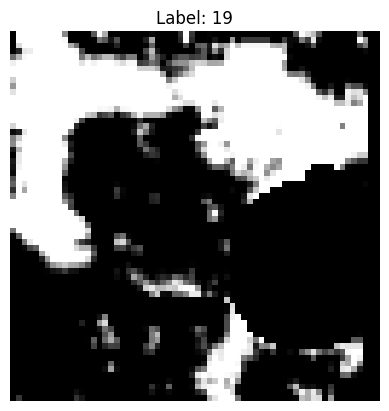

In [4]:
#@title Show a random training sample
images, labels = next(iter(train_loader_2d_aug))
idx = random.randint(0, images.size(0)-1)
img = images[idx].squeeze().numpy()  # remove channel dim if grayscale
label = labels[idx].item()
plt.imshow(img, cmap="gray")
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()

In [5]:
#@title Source (algorithm)
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torch
import torch.nn as nn
import torch.optim as optim
import cv2
import numpy as np
from PIL import Image
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import torch.nn.functional as F

class SupConLoss(nn.Module):
    """
    Supervised Contrastive Loss as in Khosla et al. (2020)
    https://arxiv.org/abs/2004.11362
    """
    def __init__(self, temperature=0.07):
        super(SupConLoss, self).__init__()
        self.temperature = temperature

    def forward(self, features, labels):
        """
        features: tensor of shape [batch_size, embed_dim]
        labels: tensor of shape [batch_size]
        """
        device = features.device
        features = F.normalize(features, dim=1)

        batch_size = features.shape[0]

        # Compute similarity matrix
        similarity_matrix = torch.matmul(features, features.T) / self.temperature

        # Mask: remove self-comparisons
        mask = torch.eye(batch_size, dtype=torch.bool).to(device)
        similarity_matrix = similarity_matrix.masked_fill(mask, -1e9)

        # Positive mask: same label
        labels = labels.contiguous().view(-1, 1)
        positive_mask = torch.eq(labels, labels.T).to(device)

        # For each sample, compute log-softmax
        log_prob = F.log_softmax(similarity_matrix, dim=1)

        # Only keep positives
        mean_log_prob_pos = (positive_mask * log_prob).sum(1) / positive_mask.sum(1).clamp(min=1)

        # Final loss
        loss = -mean_log_prob_pos.mean()
        return loss

class CNN2D(nn.Module):
    def __init__(self, num_classes, image_size=(64, 64)):
        super(CNN2D, self).__init__()
        self.image_size = image_size
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.pool3 = nn.MaxPool2d(kernel_size=2)

        # Calculate the size of the flattened features after conv and pooling
        with torch.no_grad():
            dummy_input = torch.randn(1, 1, image_size[0], image_size[1]) # (batch_size, channels, height, width)
            dummy_output = self.pool3(self.relu(self.conv3(self.pool2(self.relu(self.conv2(self.pool1(self.relu(self.conv1(dummy_input)))))))))
            flattened_size = dummy_output.shape[1] * dummy_output.shape[2] * dummy_output.shape[3]

        self.fc1 = nn.Linear(flattened_size, 512)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        # Remove the unsqueeze(1) call as ToTensor() already adds the channel dimension
        # x = x.unsqueeze(1) # Add a channel dimension (batch_size, 1, height, width)
        x = self.pool1(self.relu(self.conv1(x)))
        x = self.pool2(self.relu(self.conv2(x)))
        x = self.pool3(self.relu(self.conv3(x)))
        x = x.view(x.size(0), -1) # Flatten the tensor
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

    def get_embeddings(self, x):
        """Return embeddings before the final classification layer"""
        x = self.pool1(self.relu(self.conv1(x)))
        x = self.pool2(self.relu(self.conv2(x)))
        x = self.pool3(self.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        return x   # <-- embeddings (size = 512)

class SimilarityWeightedSupConLoss(nn.Module):
    """Supervised Contrastive Loss with class-similarity-weighted negatives."""
    def __init__(self, S_class, temperature=0.07, lambda_weight=1.0, eps=1e-8):
        super().__init__()
        self.register_buffer("S_class", S_class.float())
        self.temperature = temperature
        self.lambda_weight = lambda_weight
        self.eps = eps
        C = S_class.shape[0]
        mask_offdiag = (~torch.eye(C, dtype=torch.bool, device=S_class.device))
        self.S_bar = S_class[mask_offdiag].mean().clamp(min=eps)

    def forward(self, features, labels):
        z = F.normalize(features, dim=1)
        sim = torch.matmul(z, z.t()) / self.temperature
        B = z.size(0)
        eye = torch.eye(B, device=features.device, dtype=torch.bool)
        sim = sim.masked_fill(eye, -1e9)
        y = labels.view(-1, 1)
        pos_mask = (y == y.t()) & (~eye)
        S_pairs = self.S_class[labels][:, labels]
        w = 1.0 + self.lambda_weight * (S_pairs / self.S_bar)
        neg_mask = (~pos_mask) & (~eye)
        w = w * neg_mask.float() + pos_mask.float() + eye.float()
        exp_sim = torch.exp(sim) * (1.0 - eye.float())
        denom = (w * exp_sim).sum(dim=1, keepdim=True).clamp(min=self.eps)
        log_prob = sim - torch.log(denom)
        pos_count = pos_mask.sum(dim=1).clamp(min=1)
        mean_log_prob_pos = (pos_mask.float() * log_prob).sum(dim=1) / pos_count
        loss = -mean_log_prob_pos.mean()
        return loss

def compute_prototypes(embeddings, labels, num_classes):
    protos = []
    for c in range(num_classes):
        v = embeddings[labels == c].mean(axis=0)
        v = v / (np.linalg.norm(v) + 1e-12)
        protos.append(v)
    return np.stack(protos)  # [C, D]

def build_S_from_prototypes(model, loader, device, num_classes):
    model.eval()
    Z, Y = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            z = model.get_embeddings(x).cpu().numpy()
            Z.append(z); Y.append(y.numpy())
    Z = np.vstack(Z); Y = np.concatenate(Y)
    P = compute_prototypes(Z, Y, num_classes)           # [C, D]
    # cosine similarity in [−1, 1] → clamp to [0,1]
    S = P @ P.T
    S = np.clip(S, 0.0, 1.0)
    np.fill_diagonal(S, 0.0)
    return torch.tensor(S, dtype=torch.float32, device=device)


def get_tta_embeddings(model, x, y, n_views, tta_transform, device):
    """Apply TTA safely to a batch."""
    B = x.size(0)
    x_aug_list = []
    for img in x:  # iterate over batch
        aug_imgs = [tta_transform(img.cpu()) for _ in range(n_views)]
        x_aug_list.extend(aug_imgs)
    x_aug = torch.stack(x_aug_list).to(device)
    y_aug = y.repeat(n_views)
    emb = model.get_embeddings(x_aug)
    return emb, y_aug

def train_cnn2d(model, train_loader, val_loader, device,
                num_classes, num_epochs=100, lam_scl_weight=0.1,
                n_views=2, tta_transform=None, use_swscl=True,
                use_tta=True, update_S_every=3, patience=10,
                save_path='best_cnn_letter_model.pth',
                learning_rate=0.001,
                similarity_matrix_fn=None,
                ema_alpha=0.0):
    """
    Train CNN2D with optional SW-SCL and TTA embeddings.
    """
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    ce_loss_fn = nn.CrossEntropyLoss()
    best_val_loss = float('inf')
    epochs_no_improve = 0
    train_losses, val_losses, val_accuracies = [], [], []

    if similarity_matrix_fn is None:
        similarity_matrix_fn = build_S_from_prototypes

    S_matrix = None
    swscl_loss_fn = None

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        # --- Update similarity matrix dynamically ---
        if use_swscl and (epoch % update_S_every == 0 or S_matrix is None):
            new_S = similarity_matrix_fn(model, train_loader, device, num_classes)
            if S_matrix is None or ema_alpha == 0.0:
                S_matrix = new_S
            else:
                S_matrix = ema_alpha * S_matrix + (1 - ema_alpha) * new_S
            swscl_loss_fn = SimilarityWeightedSupConLoss(S_matrix, temperature=0.07, lambda_weight=1.0)

        for x_orig, y in train_loader:
            x_orig, y = x_orig.to(device), y.to(device)

            # --- CE Loss ---
            logits = model(x_orig)
            ce_loss = ce_loss_fn(logits, y)

            # --- SW-SCL Loss ---
            if use_swscl:
                if use_tta and tta_transform is not None and n_views > 1:
                    emb, y_aug = get_tta_embeddings(model, x_orig, y, n_views, tta_transform, device)
                else:
                    emb, y_aug = model.get_embeddings(x_orig), y
                swscl_loss = swscl_loss_fn(emb, y_aug)
            else:
                swscl_loss = 0.0

            loss = ce_loss + lam_scl_weight * swscl_loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * x_orig.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)
        train_losses.append(epoch_loss)

        # --- Validation ---
        model.eval()
        val_loss = 0.0
        correct, total = 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = ce_loss_fn(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        epoch_val_loss = val_loss / len(val_loader.dataset)
        val_accuracy = correct / total
        val_losses.append(epoch_val_loss)
        val_accuracies.append(val_accuracy)

        print(f'Epoch [{epoch+1}/{num_epochs}] '
              f'Train Loss: {epoch_loss:.4f}, '
              f'Val Loss: {epoch_val_loss:.4f}, '
              f'Val Accuracy: {val_accuracy:.4f}')

        # --- Early stopping ---
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), save_path)
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f'Early stopping triggered after {epoch+1} epochs.')
                break

    return train_losses, val_losses, val_accuracies

def evaluate(model, test_loader, device, label_encoder):
    model.eval()
    correct = 0
    total = 0
    pred, gold = [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            pred.extend(predicted.cpu().numpy())
            gold.extend(labels.cpu().numpy())

    # Inverse transform the encoded predicted and true labels to get original letter names
    pred = label_encoder.inverse_transform(pred)
    gold = label_encoder.inverse_transform(gold)

    # Display classification report
    print(classification_report(gold, pred, zero_division=0))

    # Display confusion matrix
    cm_2d = confusion_matrix(gold, pred, labels=label_encoder.classes_)

    plt.figure(figsize=(12, 10))
    sns.heatmap(cm_2d, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.savefig('cnn2d_aug_confusion_matrix.pdf', dpi=300, format='PDF')
    plt.show()

# TTA/augmentation for embeddings
tta_transform = transforms.Compose([
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.1,0.1)),
    transforms.RandomResizedCrop(size=(64,64), scale=(0.8,1.0)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2)
])

def custom_similarity_matrix(model, loader, device, num_classes):
    # e.g., compute S differently or add class-specific weighting
    S = build_S_from_prototypes(model, loader, device, num_classes)
    return S * 0.5  # example: scale similarity

## Run fCNN+SCL
* Using a custom similarity matrix


In [103]:
num_classes_2d = len(label_encoder.classes_)
image_input_size = (64, 64)  # Match preprocess_image_2d size
model = CNN2D(num_classes=num_classes_2d, image_size=image_input_size)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device) # Move model to the device

train_losses, val_losses, val_accs = train_cnn2d(
    model, train_loader_2d_aug, val_loader_2d, device, num_classes_2d,
    use_swscl=True, use_tta=True, tta_transform=tta_transform,
    similarity_matrix_fn=custom_similarity_matrix
)

Epoch [1/100] Train Loss: 2.4480, Val Loss: 1.0976, Val Accuracy: 0.6334
Epoch [2/100] Train Loss: 2.0865, Val Loss: 1.0070, Val Accuracy: 0.6737
Epoch [3/100] Train Loss: 1.9354, Val Loss: 0.9899, Val Accuracy: 0.6852
Epoch [4/100] Train Loss: 1.6067, Val Loss: 1.0040, Val Accuracy: 0.7150
Epoch [5/100] Train Loss: 1.7678, Val Loss: 0.9406, Val Accuracy: 0.7083
Epoch [6/100] Train Loss: 1.7320, Val Loss: 0.8694, Val Accuracy: 0.7198
Epoch [7/100] Train Loss: 1.4327, Val Loss: 0.7872, Val Accuracy: 0.7495
Epoch [8/100] Train Loss: 1.6933, Val Loss: 0.9254, Val Accuracy: 0.7150
Epoch [9/100] Train Loss: 1.6349, Val Loss: 0.8061, Val Accuracy: 0.7466
Epoch [10/100] Train Loss: 1.3608, Val Loss: 0.7782, Val Accuracy: 0.7390
Epoch [11/100] Train Loss: 1.6088, Val Loss: 0.8019, Val Accuracy: 0.7399
Epoch [12/100] Train Loss: 1.5775, Val Loss: 0.9591, Val Accuracy: 0.7111
Epoch [13/100] Train Loss: 1.3041, Val Loss: 0.8129, Val Accuracy: 0.7294
Epoch [14/100] Train Loss: 1.5612, Val Loss: 0.

              precision    recall  f1-score   support

       Alpha       0.61      0.64      0.62       139
        Beta       0.81      0.72      0.76        67
         Chi       0.87      0.87      0.87        85
       Delta       0.86      0.76      0.81       113
     Epsilon       0.79      0.83      0.81       138
         Eta       0.81      0.77      0.79       124
       Gamma       0.72      0.82      0.77       105
        Iota       0.76      0.77      0.76       141
       Kappa       0.81      0.93      0.86       127
      Lambda       0.64      0.53      0.58       117
          Mu       0.86      0.80      0.83       126
          Nu       0.89      0.81      0.85       134
       Omega       0.74      0.80      0.77       126
     Omicron       0.68      0.76      0.72       136
         Phi       0.81      0.90      0.85        83
          Pi       0.75      0.84      0.79       127
         Psi       0.89      0.47      0.62        17
         Rho       0.83    

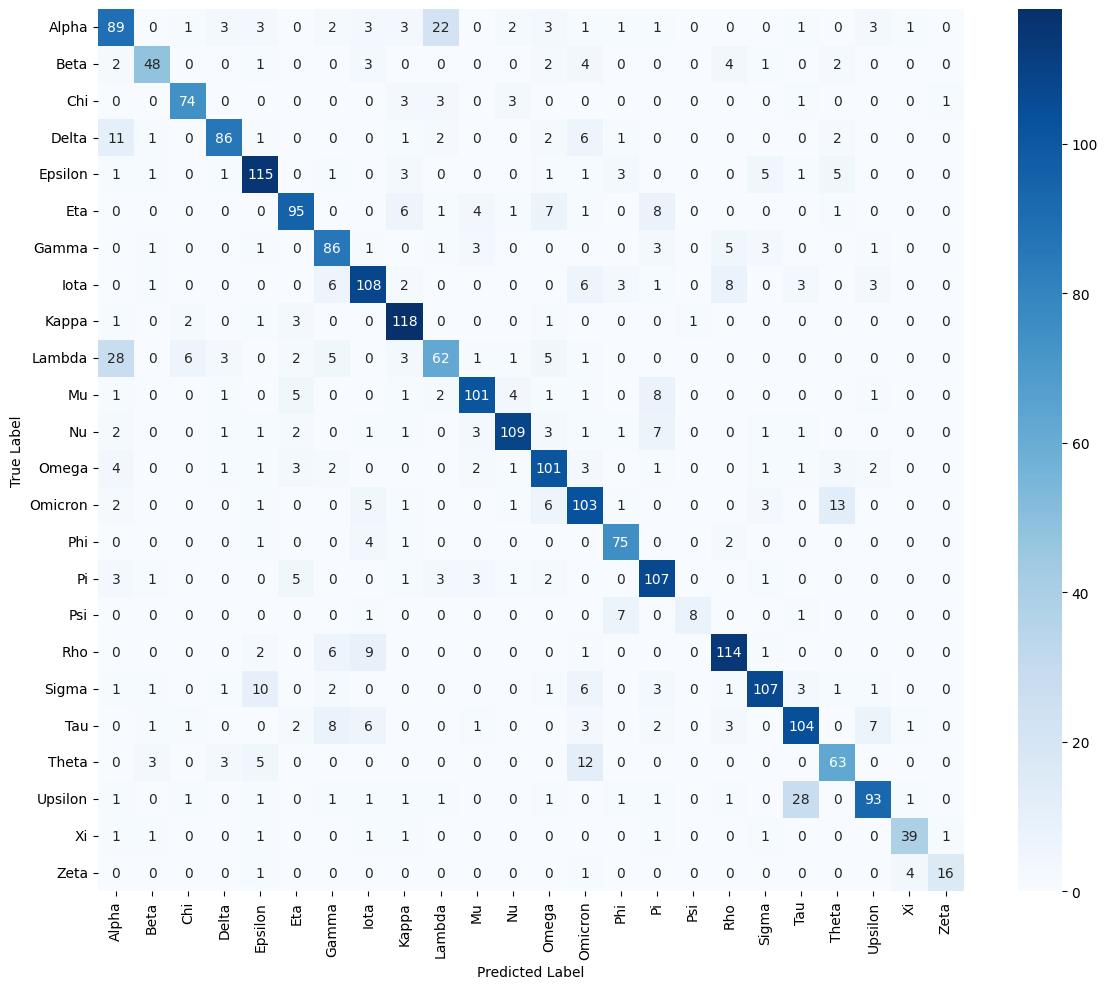

In [104]:
# Load the best model state for inference
model.load_state_dict(torch.load('best_cnn_letter_model.pth'))
evaluate(model, test_loader_2d, device, label_encoder)

## Run fCNN+SCL and Expert Priors


In [6]:
#@title Supervised Contrastive Loss
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import transforms

class SimilarityWeightedSupConLoss(nn.Module):
    """SW-SCL with optional expert-defined similarity priors."""
    def __init__(self, S_class, temperature=0.07, lambda_weight=1.0, eps=1e-8,
                 S_prior=None, alpha_prior=0.5):
        super().__init__()
        self.register_buffer("S_class", S_class.float())
        self.temperature = temperature
        self.lambda_weight = lambda_weight
        self.eps = eps

        C = S_class.shape[0]
        mask_offdiag = (~torch.eye(C, dtype=torch.bool, device=S_class.device))
        self.S_bar = S_class[mask_offdiag].mean().clamp(min=eps)

        if S_prior is not None:
            assert S_prior.shape == S_class.shape
            self.register_buffer("S_prior", S_prior.float())
            self.alpha_prior = alpha_prior
            self.S_class = (1.0 - alpha_prior) * self.S_class + alpha_prior * self.S_prior
        else:
            self.S_prior = None
            self.alpha_prior = 0.0

    def forward(self, features, labels):
        z = F.normalize(features, dim=1)
        sim = torch.matmul(z, z.t()) / self.temperature
        B = z.size(0)
        eye = torch.eye(B, device=features.device, dtype=torch.bool)
        sim = sim.masked_fill(eye, -1e9)
        y = labels.view(-1, 1)
        pos_mask = (y == y.t()) & (~eye)
        S_pairs = self.S_class[labels][:, labels]
        w = 1.0 + self.lambda_weight * (S_pairs / self.S_bar)
        neg_mask = (~pos_mask) & (~eye)
        w = w * neg_mask.float() + pos_mask.float() + eye.float()
        exp_sim = torch.exp(sim) * (1.0 - eye.float())
        denom = (w * exp_sim).sum(dim=1, keepdim=True).clamp(min=self.eps)
        log_prob = sim - torch.log(denom)
        pos_count = pos_mask.sum(dim=1).clamp(min=1)
        mean_log_prob_pos = (pos_mask.float() * log_prob).sum(dim=1) / pos_count
        loss = -mean_log_prob_pos.mean()
        return loss

def get_tta_embeddings(model, x, y, n_views, tta_transform, device):
    """Apply TTA safely to a batch of images."""
    x_aug_list = []
    for img in x:  # iterate over batch
        aug_imgs = [tta_transform(img.cpu()) for _ in range(n_views)]
        x_aug_list.extend(aug_imgs)
    x_aug = torch.stack(x_aug_list).to(device)
    y_aug = y.repeat(n_views)
    emb = model.get_embeddings(x_aug)
    return emb, y_aug

def train_cnn2d(model, train_loader, val_loader, device,
                num_classes, num_epochs=100, lam_scl_weight=0.1,
                n_views=2, tta_transform=None, use_swscl=True,
                use_tta=True, update_S_every=3, patience=10,
                save_path='best_cnn_model.pth', learning_rate=0.001,
                similarity_matrix_fn=None, S_prior=None, alpha_prior=0.5,
                ema_alpha=0.0):
    """
    Train CNN2D with optional SW-SCL, expert priors, and TTA.
    """
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    ce_loss_fn = nn.CrossEntropyLoss()
    best_val_loss = float('inf')
    epochs_no_improve = 0
    train_losses, val_losses, val_accuracies = [], [], []

    if similarity_matrix_fn is None:
        similarity_matrix_fn = build_S_from_prototypes

    S_matrix = None
    swscl_loss_fn = None

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        # --- Update similarity matrix dynamically ---
        if use_swscl and (epoch % update_S_every == 0 or S_matrix is None):
            new_S = similarity_matrix_fn(model, train_loader, device, num_classes)
            if S_matrix is None or ema_alpha == 0.0:
                S_matrix = new_S
            else:
                S_matrix = ema_alpha * S_matrix + (1 - ema_alpha) * new_S

            swscl_loss_fn = SimilarityWeightedSupConLoss(
                S_matrix,
                temperature=0.07,
                lambda_weight=1.0,
                S_prior=S_prior,
                alpha_prior=alpha_prior
            )

        for x_orig, y in train_loader:
            x_orig, y = x_orig.to(device), y.to(device)

            # --- CE Loss ---
            logits = model(x_orig)
            ce_loss = ce_loss_fn(logits, y)

            # --- SW-SCL Loss ---
            if use_swscl:
                if use_tta and tta_transform is not None and n_views > 1:
                    emb, y_aug = get_tta_embeddings(model, x_orig, y, n_views, tta_transform, device)
                else:
                    emb, y_aug = model.get_embeddings(x_orig), y
                swscl_loss = swscl_loss_fn(emb, y_aug)
            else:
                swscl_loss = 0.0

            # --- Total Loss ---
            loss = ce_loss + lam_scl_weight * swscl_loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * x_orig.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)
        train_losses.append(epoch_loss)

        # --- Validation ---
        model.eval()
        val_loss = 0.0
        correct, total = 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = ce_loss_fn(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        epoch_val_loss = val_loss / len(val_loader.dataset)
        val_accuracy = correct / total
        val_losses.append(epoch_val_loss)
        val_accuracies.append(val_accuracy)

        print(f'Epoch [{epoch+1}/{num_epochs}] '
              f'Train Loss: {epoch_loss:.4f}, '
              f'Val Loss: {epoch_val_loss:.4f}, '
              f'Val Accuracy: {val_accuracy:.4f}')

        # --- Early stopping ---
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), save_path)
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f'Early stopping triggered after {epoch+1} epochs.')
                break

    return train_losses, val_losses, val_accuracies

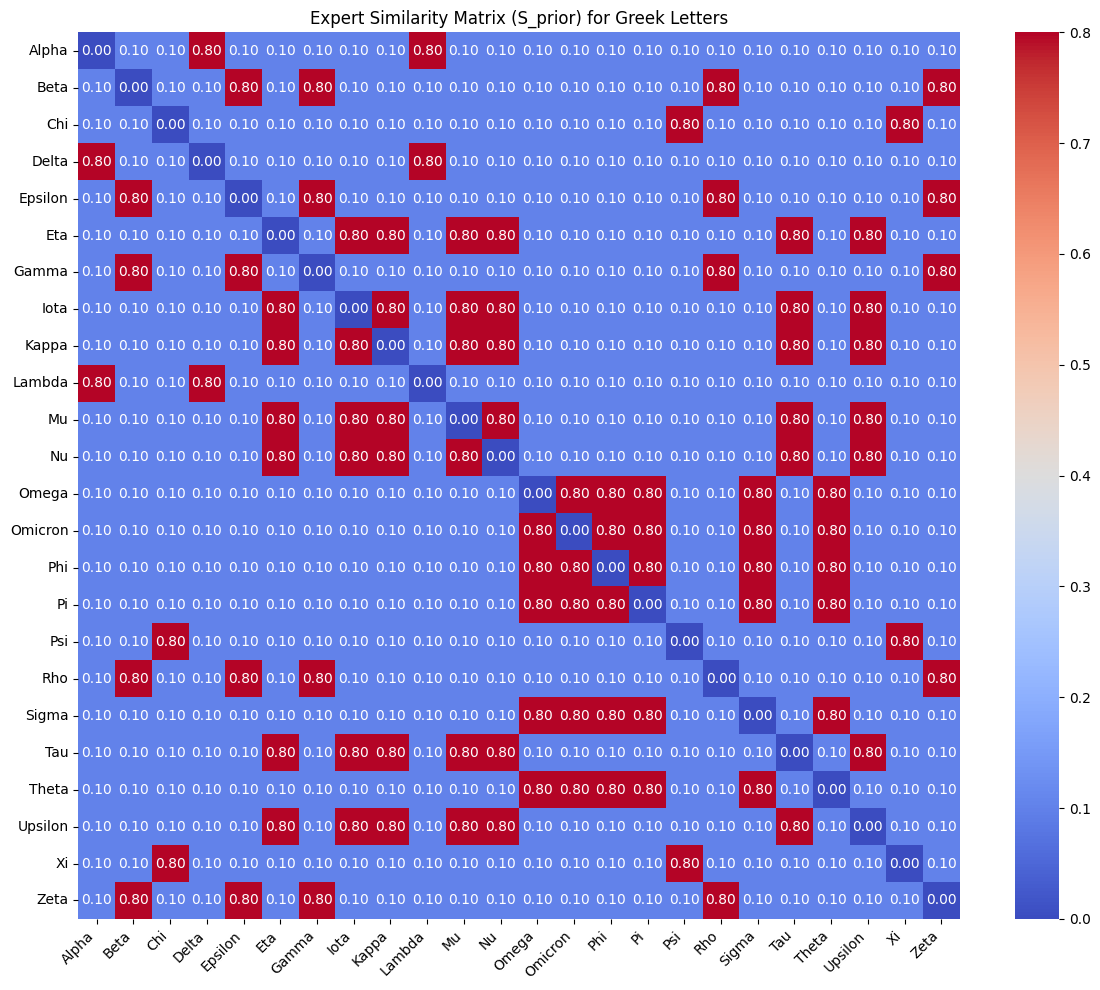

In [7]:
#@title The Expert Priors
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Groupings (from previous step)
letter_groups = {
    "straight_lines": ['Iota', 'Eta', 'Tau', 'Lambda', 'Mu', 'Nu', 'Upsilon', 'Kappa'],
    "triangles": ['Delta', 'Lambda', 'Alpha'],
    "curves": ['Omicron', 'Omega', 'Phi', 'Pi', 'Theta', 'Sigma'],
    "loops": ['Beta', 'Epsilon', 'Gamma', 'Zeta', 'Rho'],
    "complex": ['Psi', 'Xi', 'Chi']
}

group_names = list(letter_groups.keys())
group_to_labels = {g: set(letter_groups[g]) for g in group_names}

# Map class name to group index
label_to_group = {}
for g, labels in group_to_labels.items():
    for l in labels:
        label_to_group[l] = g

class_names = label_encoder.classes_
num_classes = len(class_names)

# Initialize S_prior
S_prior = np.zeros((num_classes, num_classes), dtype=np.float32)

# Fill S_prior: high similarity within same group, low between groups
high_sim = 0.8
low_sim = 0.1

for i, ci in enumerate(class_names):
    for j, cj in enumerate(class_names):
        if i == j:
            S_prior[i,j] = 0.0  # diagonal = 0
        elif label_to_group[ci] == label_to_group[cj]:
            S_prior[i,j] = high_sim
        else:
            S_prior[i,j] = low_sim

# Convert to torch tensor
S_prior = torch.tensor(S_prior, dtype=torch.float32)

plt.figure(figsize=(12,10))
sns.heatmap(S_prior.numpy(),
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            cmap="coolwarm",
            annot=True, fmt=".2f", cbar=True)

plt.title("Expert Similarity Matrix (S_prior) for Greek Letters")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [8]:
num_classes_2d = len(label_encoder.classes_)
image_input_size = (64, 64)  # Match preprocess_image_2d size
model = CNN2D(num_classes=num_classes_2d, image_size=image_input_size)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device) # Move model to the device

train_losses, val_losses, val_accs = train_cnn2d(
    model, train_loader_2d_aug, val_loader_2d, device, num_classes_2d,
    use_swscl=True, use_tta=True, tta_transform=tta_transform,
    similarity_matrix_fn=custom_similarity_matrix,
    S_prior=S_prior.to(device),
    alpha_prior=0.3
)

Epoch [1/100] Train Loss: 2.4005, Val Loss: 1.0671, Val Accuracy: 0.6545
Epoch [2/100] Train Loss: 2.0521, Val Loss: 0.9635, Val Accuracy: 0.6996
Epoch [3/100] Train Loss: 1.9239, Val Loss: 0.9639, Val Accuracy: 0.6987
Epoch [4/100] Train Loss: 1.5905, Val Loss: 0.9695, Val Accuracy: 0.6871
Epoch [5/100] Train Loss: 1.7818, Val Loss: 0.8762, Val Accuracy: 0.7198
Epoch [6/100] Train Loss: 1.7246, Val Loss: 0.9049, Val Accuracy: 0.7284
Epoch [7/100] Train Loss: 1.4281, Val Loss: 0.9192, Val Accuracy: 0.7083
Epoch [8/100] Train Loss: 1.6353, Val Loss: 0.8489, Val Accuracy: 0.7505
Epoch [9/100] Train Loss: 1.5948, Val Loss: 0.8744, Val Accuracy: 0.7332
Epoch [10/100] Train Loss: 1.3311, Val Loss: 0.7902, Val Accuracy: 0.7438
Epoch [11/100] Train Loss: 1.5585, Val Loss: 0.8133, Val Accuracy: 0.7274
Epoch [12/100] Train Loss: 1.5353, Val Loss: 0.7607, Val Accuracy: 0.7543
Epoch [13/100] Train Loss: 1.2600, Val Loss: 0.7650, Val Accuracy: 0.7524
Epoch [14/100] Train Loss: 1.5101, Val Loss: 0.

              precision    recall  f1-score   support

       Alpha       0.62      0.58      0.59       139
        Beta       0.88      0.69      0.77        67
         Chi       0.86      0.88      0.87        85
       Delta       0.74      0.76      0.75       113
     Epsilon       0.88      0.82      0.85       138
         Eta       0.74      0.81      0.78       124
       Gamma       0.72      0.74      0.73       105
        Iota       0.77      0.67      0.71       141
       Kappa       0.90      0.84      0.87       127
      Lambda       0.63      0.57      0.60       117
          Mu       0.79      0.80      0.80       126
          Nu       0.89      0.80      0.84       134
       Omega       0.82      0.87      0.85       126
     Omicron       0.68      0.85      0.75       136
         Phi       0.77      0.87      0.81        83
          Pi       0.74      0.87      0.80       127
         Psi       0.56      0.29      0.38        17
         Rho       0.85    

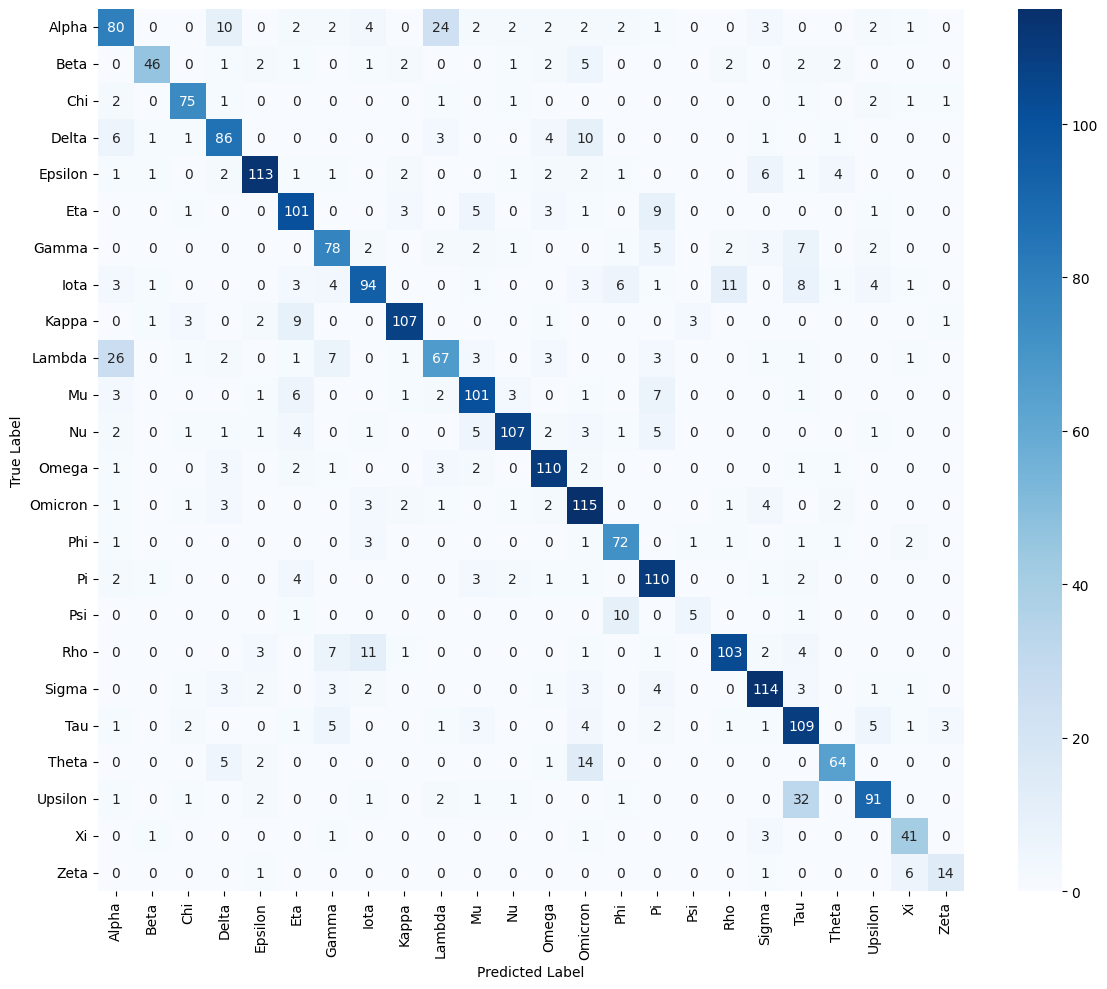

In [9]:
# Load the best model state for inference
model.load_state_dict(torch.load('best_cnn_model.pth'))
evaluate(model, test_loader_2d, device, label_encoder)

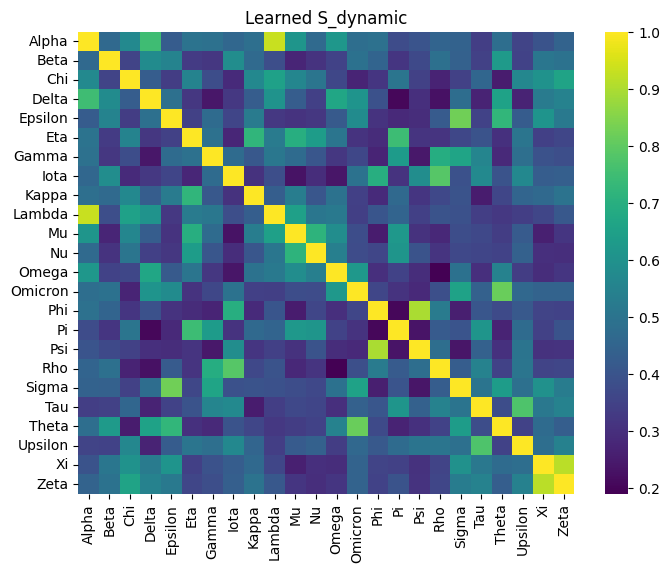

In [10]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns

def compute_class_prototypes(model, dataloader, device):
    model.eval()
    embeddings, labels = [], []

    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(device)
            feats = model.get_embeddings(x)   # assuming model.encoder gives embeddings
            embeddings.append(feats.cpu())
            labels.append(y)

    embeddings = torch.cat(embeddings, dim=0)
    labels = torch.cat(labels, dim=0)

    prototypes = []
    for c in torch.unique(labels):
        mask = (labels == c)
        proto = embeddings[mask].mean(dim=0)
        prototypes.append(proto)

    return torch.stack(prototypes)

def compute_similarity_matrix(prototypes):
    # cosine similarity between all class prototypes
    sim = F.cosine_similarity(
        prototypes.unsqueeze(1),  # (C,1,D)
        prototypes.unsqueeze(0),  # (1,C,D)
        dim=-1
    )
    return sim

def plot_similarity_matrix(S, class_names=None, title="S_dynamic"):
    plt.figure(figsize=(8,6))
    sns.heatmap(S.cpu().numpy(), annot=False, cmap="viridis",
                xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.show()

# Usage after training
prototypes = compute_class_prototypes(model, train_loader_2d_aug, device)
S_dynamic = compute_similarity_matrix(prototypes)
plot_similarity_matrix(S_dynamic, class_names=class_names, title="Learned S_dynamic")

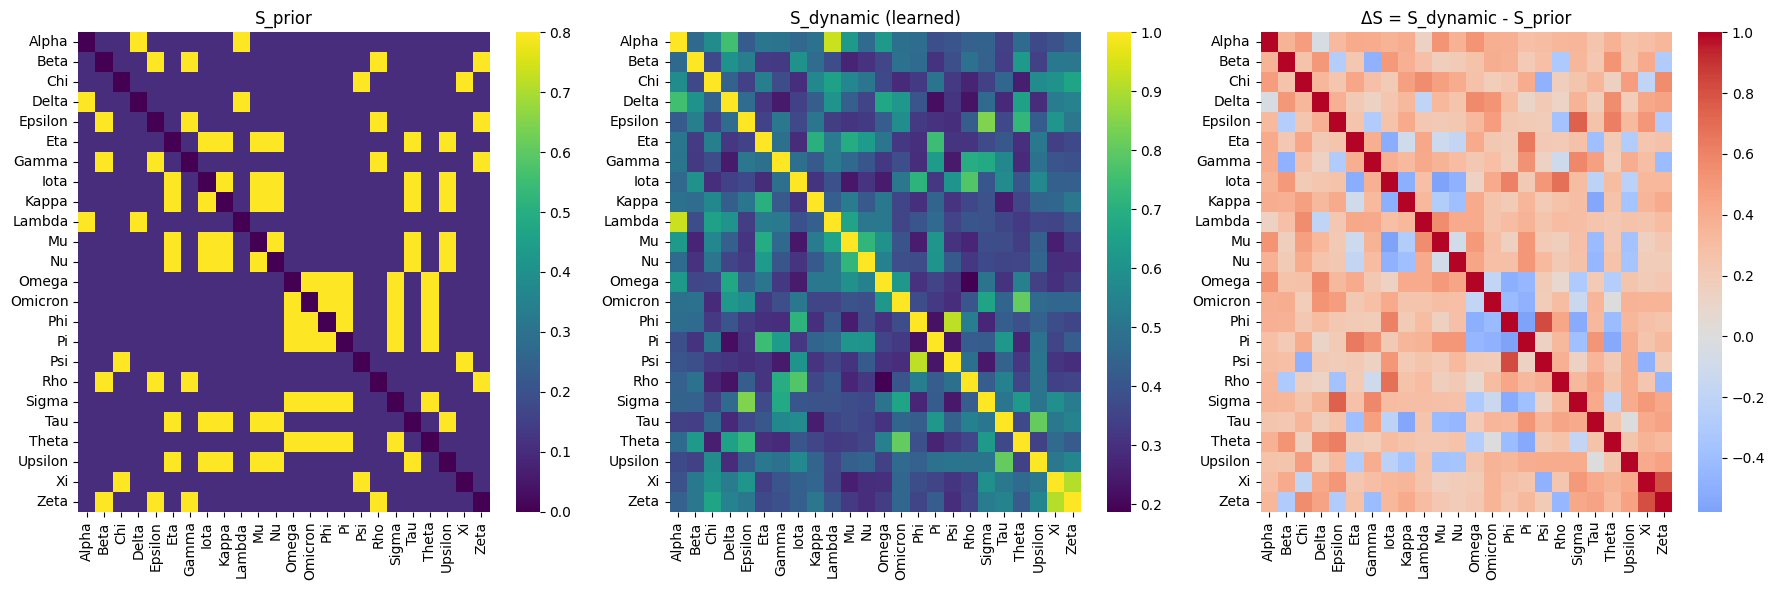

In [11]:
def plot_similarity_matrices(S_prior, S_dynamic, class_names=None):
    delta = S_dynamic - S_prior

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    sns.heatmap(S_prior.cpu().numpy(), cmap="viridis", ax=axes[0],
                xticklabels=class_names, yticklabels=class_names)
    axes[0].set_title("S_prior")

    sns.heatmap(S_dynamic.cpu().numpy(), cmap="viridis", ax=axes[1],
                xticklabels=class_names, yticklabels=class_names)
    axes[1].set_title("S_dynamic (learned)")

    sns.heatmap(delta.cpu().numpy(), cmap="coolwarm", center=0, ax=axes[2],
                xticklabels=class_names, yticklabels=class_names)
    axes[2].set_title("ΔS = S_dynamic - S_prior")

    plt.tight_layout()
    plt.show()

# Example usage after training
prototypes = compute_class_prototypes(model, train_loader_2d_aug, device)
S_dynamic = compute_similarity_matrix(prototypes)

plot_similarity_matrices(S_prior, S_dynamic, class_names=label_encoder.classes_)